# siMYC and MYC-ASO correlation analysis

Compare the transcriptional effects of siMYC with MYC-ASO results generated by both Plasmidsaurus and DESeq2 at 48h and 72h.

- Gene-level comparisons match differential-expression results by Ensembl ID and correlate LFC.
- Hallmark comparisons match normalized Hallmark names and correlate NES.
- Plasmidsaurus significance is defined as gene `FDR < 0.05` or hallmark `FDR_Q_VAL < 0.05`.
- DESeq2 significance is defined as gene `padj < 0.05` or hallmark `p.adjust < 0.05`.
- "Significant in both" does not require matching effect direction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr

import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

DATA_DIR = Path("/media/scratch/fy2306/projects/base_editing/data/ASO_rnaseq/siMYC_plasmidsaurus/plasmidsaurus")
FDR_THRESHOLD = 0.05

INPUTS = {
    "48h": {
        "siMYC_dge": DATA_DIR / "F5HJM7-siControl-48h_vs_siMYC-48h-dge.csv",
        "ASO_dge": DATA_DIR / "F5HJM7-Control-ASO-48h_vs_MYC-ASO-48h-dge.csv",
        "siMYC_hallmarks": DATA_DIR / "siControl-48h_vs_siMYC-48h.hallmarks.csv",
        "ASO_hallmarks": DATA_DIR / "Control-ASO-48h_vs_MYC-ASO-48h.hallmarks.csv",
    },
    "72h": {
        "siMYC_dge": DATA_DIR / "F5HJM7-siControl-72h_vs_siMYC-72h-dge.csv",
        "ASO_dge": DATA_DIR / "F5HJM7-Control-ASO-72h_vs_MYC-ASO-72h-dge.csv",
        "siMYC_hallmarks": DATA_DIR / "siControl-72h_vs_siMYC-72h.hallmarks.csv",
        "ASO_hallmarks": DATA_DIR / "Control-ASO-72h_vs_MYC-ASO-72h.hallmarks.csv",
    },
}

assert all(path.exists() for files in INPUTS.values() for path in files.values())
DATA_DIR

PosixPath('/media/scratch/fy2306/projects/base_editing/data/ASO_rnaseq/siMYC_plasmidsaurus/plasmidsaurus')

## Functions

In [2]:
from matplotlib.ticker import MultipleLocator


def _prepare_unique_rows(frame, key, columns):
    result = frame[[key, *columns]].copy()
    result = result.dropna(subset=[key, *columns])
    result = result.drop_duplicates(subset=key, keep=False)
    for column in columns:
        if pd.api.types.is_numeric_dtype(result[column]):
            result = result[np.isfinite(result[column])]
    return result


def load_shared_genes(si_path, aso_path):
    si = pd.read_csv(si_path)
    aso = pd.read_csv(aso_path)
    si = _prepare_unique_rows(si, "EnsemblID", ["gene_name", "logFC", "FDR"]).rename(
        columns={"gene_name": "gene_name_siMYC", "logFC": "siMYC_logFC", "FDR": "siMYC_FDR"}
    )
    aso = _prepare_unique_rows(aso, "EnsemblID", ["gene_name", "logFC", "FDR"]).rename(
        columns={"gene_name": "gene_name_ASO", "logFC": "ASO_logFC", "FDR": "ASO_FDR"}
    )
    shared = si.merge(aso, on="EnsemblID", how="inner", validate="one_to_one")
    shared["gene_name"] = shared["gene_name_siMYC"].fillna(shared["gene_name_ASO"])
    shared["siMYC_significant"] = shared["siMYC_FDR"] < FDR_THRESHOLD
    shared["both_significant"] = shared["siMYC_significant"] & (shared["ASO_FDR"] < FDR_THRESHOLD)
    shared["same_direction"] = np.sign(shared["siMYC_logFC"]) == np.sign(shared["ASO_logFC"])
    return shared


def load_shared_hallmarks(si_path, aso_path):
    si = _prepare_unique_rows(pd.read_csv(si_path), "TERM", ["NES", "FDR_Q_VAL"]).rename(
        columns={"NES": "siMYC_NES", "FDR_Q_VAL": "siMYC_FDR_Q_VAL"}
    )
    aso = _prepare_unique_rows(pd.read_csv(aso_path), "TERM", ["NES", "FDR_Q_VAL"]).rename(
        columns={"NES": "ASO_NES", "FDR_Q_VAL": "ASO_FDR_Q_VAL"}
    )
    shared = si.merge(aso, on="TERM", how="inner", validate="one_to_one")
    shared["both_significant"] = (
        (shared["siMYC_FDR_Q_VAL"] < FDR_THRESHOLD) & (shared["ASO_FDR_Q_VAL"] < FDR_THRESHOLD)
    )
    shared["same_direction"] = np.sign(shared["siMYC_NES"]) == np.sign(shared["ASO_NES"])
    return shared


def correlation_stats(frame, x, y):
    if len(frame) < 2 or frame[x].nunique() < 2 or frame[y].nunique() < 2:
        return {"n": len(frame), "pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan}
    pearson = pearsonr(frame[x], frame[y])
    spearman = spearmanr(frame[x], frame[y])
    return {"n": len(frame), "pearson_r": pearson.statistic, "pearson_p": pearson.pvalue,
            "spearman_rho": spearman.statistic, "spearman_p": spearman.pvalue}


def plot_correlation_scatter(data_by_timepoint, x, y, xlabel, ylabel, point_size=15, annotate=None, save_path = None, quadrant=False):
	figsize = (6, 4) if annotate else (4, 4)
	for timepoint, frame in data_by_timepoint.items():
		plt.figure(figsize=figsize)
		stats = correlation_stats(frame, x, y)
		plt.scatter(data=frame, x=x, y=y, s=point_size, alpha=0.8, c='black')
		# if frame[x].nunique() >= 2:
		# 	sns.regplot(data=frame, x=x, y=y, ax=ax, scatter=False, ci=None,
		# 				line_kws={"color": "#C43B3B", "linewidth": 1})
		# plt.axhline(0, color="black", linewidth=0.4, alpha=0.6, linestyle="--")
		# plt.axvline(0, color="black", linewidth=0.4, alpha=0.6, linestyle="--")
		plt.title(f"{timepoint} (n = {stats['n']:,})", fontsize=13)
		ax = plt.gca()
		ax.spines['top'].set_visible(False)
		ax.spines['right'].set_visible(False)
		plt.xlabel(xlabel, fontsize=12)
		plt.ylabel(ylabel, fontsize=12)
		stats_text = ax.text(0.03, 0.97,
								f"Pearson r = {stats['pearson_r']:.3f}\n(p={stats['pearson_p']:.2g})",
								transform=ax.transAxes, va="top",
								fontsize=12)
		if annotate:
			xmax = frame[x].max()
			xmin = frame[x].min()
			x_range = xmax - xmin
			x_offset = x_range * 0.05
			x_text = xmax + x_range * 0.15

			data_for_labels = sorted(zip(frame[x], frame[y], frame[annotate]), key=lambda v: v[1])
			n_labels = len(data_for_labels)

			y_label_positions = np.linspace(min(frame[y]), max(frame[y]), n_labels)

			for (xi, yi, label), y_text in zip(data_for_labels, y_label_positions):
				ax.plot([xi, x_text], [yi, y_text],
						lw=0.5, color='grey', alpha=0.7)

				ax.text(
					x_text, y_text, label,
					va='center', ha='left',
					fontsize=12, color='black'
				)

			ax.set_xlim(xmin - x_offset, x_text + x_offset)
		ax.xaxis.set_major_locator(MultipleLocator(1))
		ax.yaxis.set_major_locator(MultipleLocator(1))
		plt.tick_params(axis='both', labelsize=12)
		plt.tight_layout()
		
		if save_path:
			plt.savefig(f"{save_path}.{timepoint}h.pdf", dpi=300, bbox_inches='tight', format="pdf")
		plt.show()

		if quadrant:
			print(f"Quadrant counts for {timepoint}h:")
			print(f"Q1 (siMYC > 0, ASO > 0): {((frame[x] > 0) & (frame[y] > 0)).sum()}")
			print(f"Q2 (siMYC > 0, ASO < 0): {((frame[x] > 0) & (frame[y] < 0)).sum()}")
			print(f"Q3 (siMYC < 0, ASO < 0): {((frame[x] < 0) & (frame[y] < 0)).sum()}")
			print(f"Q4 (siMYC < 0, ASO > 0): {((frame[x] < 0) & (frame[y] > 0)).sum()}")

def plot_correlation_hexbin(data_by_timepoint, x, y, xlabel, ylabel, save_path = None):
	figsize = (4, 4)
	for timepoint, frame in data_by_timepoint.items():
		fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
		stats = correlation_stats(frame, x, y)
		hb = ax.hexbin(x=frame[x], y=frame[y], gridsize=50, cmap="flare", mincnt=1, vmin = 1, vmax = 50)
		# if frame[x].nunique() >= 2:
		# 	sns.regplot(data=frame, x=x, y=y, ax=ax, scatter=False, ci=None,
		# 				line_kws={"color": "#C43B3B", "linewidth": 1})
		cax = ax.inset_axes([0.05, 0.15, 0.25, 0.03])
		cb = plt.colorbar(hb, cax=cax, orientation='horizontal')
		cb.set_label("gene count", fontsize=10)
		cb.ax.tick_params(labelsize=10)
		finite_values = np.concatenate([frame[x].to_numpy(), frame[y].to_numpy()])
		low, high = finite_values.min(), finite_values.max()
		margin_fraction = 0.06
		margin = max((high - low) * margin_fraction, 0.1)
		limits = (low - margin, high + margin)
		ax.axhline(0, color="grey", linewidth=0.7, alpha=0.6)
		ax.axvline(0, color="grey", linewidth=0.7, alpha=0.6)
		ax.set_title(f"{timepoint} (n = {stats['n']:,})", fontsize=13)
		ax.spines['top'].set_visible(False)
		ax.spines['right'].set_visible(False)
		plt.xlabel(xlabel, fontsize=12)
		plt.ylabel(ylabel, fontsize=12)
		stats_text = ax.text(0.03, 0.97,
						f"Pearson r = {stats['pearson_r']:.3f}\n(p={stats['pearson_p']:.2g})",
						transform=ax.transAxes, va="top",
						fontsize=12)
		ax.xaxis.set_major_locator(MultipleLocator(1))
		ax.yaxis.set_major_locator(MultipleLocator(1))
		plt.tick_params(axis='both', labelsize=12)
		plt.tight_layout()
		if save_path:
			plt.savefig(f"{save_path}.{timepoint}h.pdf", dpi=300, bbox_inches='tight', format="pdf")
		plt.show()


def correlation_summary(data_by_timepoint, x, y, subset):
    rows = []
    for timepoint, frame in data_by_timepoint.items():
        rows.append({"timepoint": timepoint, "subset": subset, **correlation_stats(frame, x, y)})
    return pd.DataFrame(rows).set_index(["timepoint", "subset"])

## Gene-level LFC correlations

The all-gene analysis includes every unique `EnsemblID` with finite LFC and FDR values in both corresponding files.

In [3]:
genes = {
    timepoint: load_shared_genes(files["siMYC_dge"], files["ASO_dge"])
    for timepoint, files in INPUTS.items()
}
genes_siMYC_significant = {tp: frame.loc[frame["siMYC_significant"]].copy() for tp, frame in genes.items()}
genes_both_significant = {tp: frame.loc[frame["both_significant"]].copy() for tp, frame in genes.items()}

gene_counts = pd.DataFrame({
    tp: {
        "all shared genes": len(frame),
        "significant in siMYC": frame["siMYC_significant"].sum(),
        "significant in both": frame["both_significant"].sum(),
        "both significant, same direction": (frame["both_significant"] & frame["same_direction"]).sum(),
    }
    for tp, frame in genes.items()
}).T
gene_counts

,all shared genes,significant in siMYC,significant in both,"both significant, same direction"
48h,14176,6887,326,224
72h,14216,7918,344,222


In [4]:
gene_correlation_summary = pd.concat([
    correlation_summary(genes, "siMYC_logFC", "ASO_logFC", "all shared genes"),
    correlation_summary(genes_siMYC_significant, "siMYC_logFC", "ASO_logFC", "significant in siMYC"),
    correlation_summary(genes_both_significant, "siMYC_logFC", "ASO_logFC", "significant in both"),
])
gene_correlation_summary

,,n,pearson_r,pearson_p,spearman_rho,spearman_p
timepoint,subset,,,,,
48h,all shared genes,14176,0.185134,1.645167e-109,0.160117,4.817842e-82
72h,all shared genes,14216,0.128424,2.430409e-53,0.099661,1.033369e-32
48h,significant in siMYC,6887,0.271024,3.084449e-116,0.243680,1.184525e-93
72h,significant in siMYC,7918,0.171066,4.622710e-53,0.132663,2.019603e-32
48h,significant in both,326,0.477303,5.938917e-20,0.458736,2.271937e-18
72h,significant in both,344,0.389948,6.127736e-14,0.382936,1.853661e-13


/tmp/ipykernel_2040064/2549449317.py:148: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


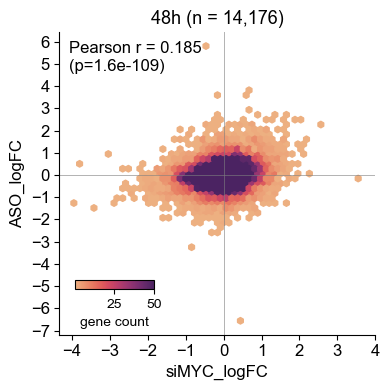

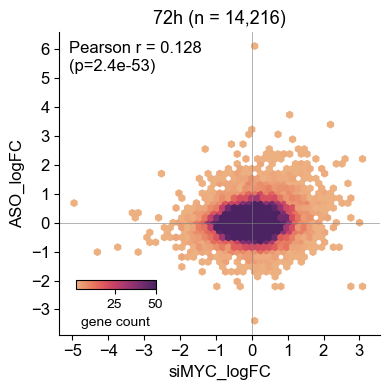

In [5]:
plot_correlation_hexbin(genes, "siMYC_logFC", "ASO_logFC", "siMYC_logFC", "ASO_logFC")

/tmp/ipykernel_2040064/2549449317.py:148: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


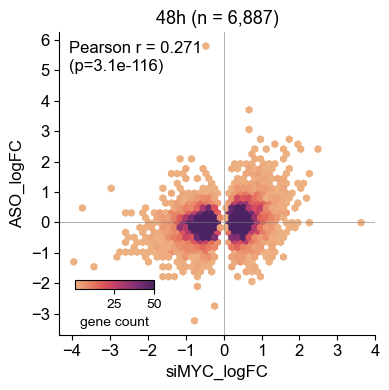

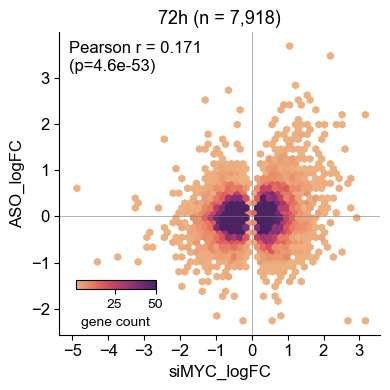

In [6]:
plot_correlation_hexbin(genes_siMYC_significant, "siMYC_logFC", "ASO_logFC", "siMYC_logFC", "ASO_logFC")

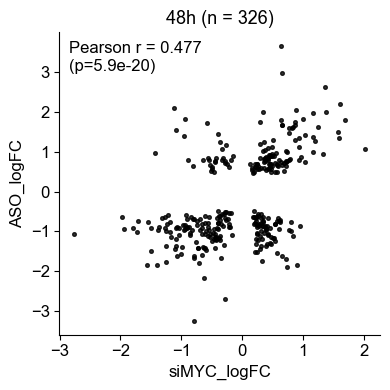

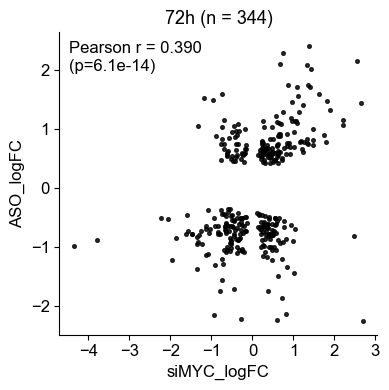

In [7]:
plot_correlation_scatter(genes_both_significant, "siMYC_logFC", "ASO_logFC", "siMYC_logFC", "ASO_logFC", point_size=7)

### Genes significant in both

Tables are sorted by the larger of the two FDR values, so genes with the strongest joint evidence appear first.

In [8]:
for timepoint, frame in genes_both_significant.items():
    print(f"{timepoint}: {len(frame):,} genes significant in both")
    display(
        frame.assign(max_FDR=frame[["siMYC_FDR", "ASO_FDR"]].max(axis=1))
        .sort_values(["max_FDR", "gene_name"])
        [["EnsemblID", "gene_name", "siMYC_logFC", "ASO_logFC", "siMYC_FDR", "ASO_FDR", "same_direction"]]
    )

48h: 326 genes significant in both


,EnsemblID,gene_name,siMYC_logFC,ASO_logFC,siMYC_FDR,ASO_FDR,same_direction
1075,ENSG00000305512,ENSG00000305512,-0.786420,-3.238940,4.903960e-08,0.002356,True
2328,ENSG00000288825,H2AC18,0.657491,1.659390,1.814890e-05,0.004901,True
2384,ENSG00000288859,H2AC19,0.647154,1.659230,2.245650e-05,0.004901,True
319,ENSG00000110031,LPXN,-1.062180,-1.615850,2.291910e-11,0.004901,True
5062,ENSG00000240476,LINC00973,-0.344680,-1.655480,6.702700e-03,0.004901,True
...,...,...,...,...,...,...,...
5759,ENSG00000074211,PPP2R2C,-0.526481,-1.151440,1.518650e-02,0.049596,True
4899,ENSG00000289223,ENSG00000289223,1.194530,1.275670,5.287740e-03,0.049895,True
2130,ENSG00000111684,LPCAT3,0.741710,0.993030,9.252530e-06,0.049895,True
5201,ENSG00000141562,NARF,0.340021,-0.750802,7.914190e-03,0.049895,False


72h: 344 genes significant in both


,EnsemblID,gene_name,siMYC_logFC,ASO_logFC,siMYC_FDR,ASO_FDR,same_direction
1430,ENSG00000305512,ENSG00000305512,-0.800851,-1.757560,3.591200e-08,0.004645,True
155,ENSG00000117318,ID3,1.374780,2.413770,1.013640e-13,0.004645,True
686,ENSG00000110031,LPXN,-1.136750,-1.148100,2.141620e-10,0.005544,True
5976,ENSG00000175567,UCP2,-0.283470,-2.231690,6.245260e-03,0.004645,True
4252,ENSG00000179242,CDH4,0.372432,-1.748960,3.536900e-04,0.012924,False
...,...,...,...,...,...,...,...
6552,ENSG00000173120,KDM2A,-0.200770,0.434876,1.255050e-02,0.049310,False
905,ENSG00000095319,NUP188,-0.742508,-0.450093,1.534420e-09,0.049310,True
7908,ENSG00000128185,DGCR6L,0.238716,-0.669899,4.979000e-02,0.047841,False
7907,ENSG00000143570,SLC39A1,0.144395,0.557702,4.979000e-02,0.048236,True


## Hallmark gene-set NES correlations

All 50 shared Hallmark terms are included in the all-gene-set analysis. The filtered analysis retains terms with `FDR_Q_VAL < 0.05` in both siMYC and MYC-ASO.

In [9]:
hallmarks = {
    timepoint: load_shared_hallmarks(files["siMYC_hallmarks"], files["ASO_hallmarks"])
    for timepoint, files in INPUTS.items()
}
hallmarks_both_significant = {tp: frame.loc[frame["both_significant"]].copy() for tp, frame in hallmarks.items()}

hallmark_counts = pd.DataFrame({
    tp: {
        "all shared hallmark sets": len(frame),
        "significant in both": frame["both_significant"].sum(),
        "both significant, same direction": (frame["both_significant"] & frame["same_direction"]).sum(),
    }
    for tp, frame in hallmarks.items()
}).T
hallmark_counts

,all shared hallmark sets,significant in both,"both significant, same direction"
48h,50,10,7
72h,50,5,5


In [10]:
hallmark_correlation_summary = pd.concat([
    correlation_summary(hallmarks, "siMYC_NES", "ASO_NES", "all shared hallmark sets"),
    correlation_summary(hallmarks_both_significant, "siMYC_NES", "ASO_NES", "significant in both"),
])
hallmark_correlation_summary

,,n,pearson_r,pearson_p,spearman_rho,spearman_p
timepoint,subset,,,,,
48h,all shared hallmark sets,50,0.348475,0.013137,0.358367,0.010605
72h,all shared hallmark sets,50,0.350691,0.012529,0.393998,0.004640
48h,significant in both,10,0.541254,0.106149,0.466667,0.173939
72h,significant in both,5,0.995060,0.000417,0.600000,0.284757


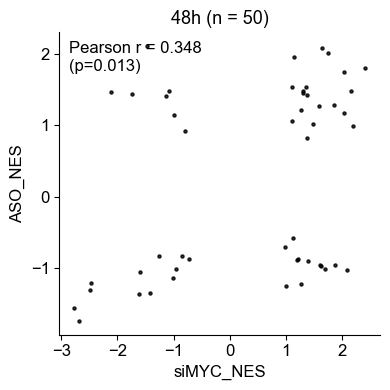

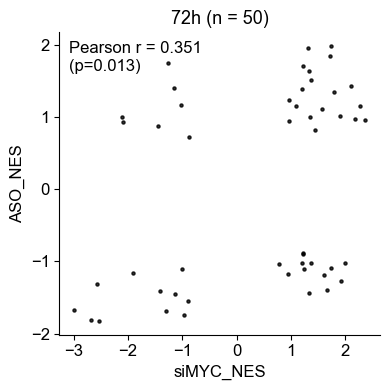

In [11]:
plot_correlation_scatter(hallmarks, "siMYC_NES", "ASO_NES", "siMYC_NES", "ASO_NES", point_size=5)

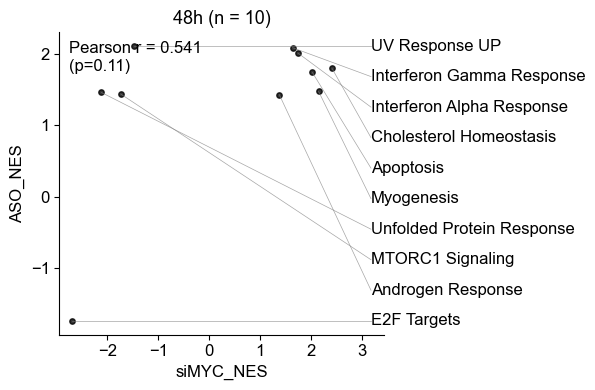

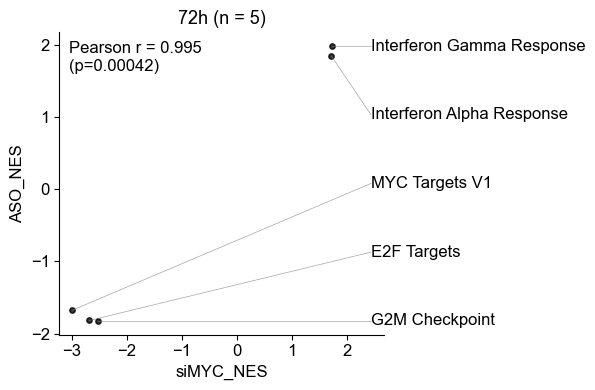

In [12]:
plot_correlation_scatter(hallmarks_both_significant, "siMYC_NES", "ASO_NES", "siMYC_NES", "ASO_NES", point_size=15, annotate="TERM")

### Hallmark sets significant in both

In [13]:
for timepoint, frame in hallmarks_both_significant.items():
    print(f"{timepoint}: {len(frame):,} hallmark sets significant in both")
    display(
        frame.assign(max_FDR_Q_VAL=frame[["siMYC_FDR_Q_VAL", "ASO_FDR_Q_VAL"]].max(axis=1))
        .sort_values(["max_FDR_Q_VAL", "TERM"])
        [["TERM", "siMYC_NES", "ASO_NES", "siMYC_FDR_Q_VAL", "ASO_FDR_Q_VAL", "same_direction"]]
    )

48h: 10 hallmark sets significant in both


,TERM,siMYC_NES,ASO_NES,siMYC_FDR_Q_VAL,ASO_FDR_Q_VAL,same_direction
4,Cholesterol Homeostasis,2.408136,1.802418,0.001000,0.001615,True
10,Apoptosis,2.021175,1.747336,0.001000,0.002356,True
13,Interferon Alpha Response,1.738119,2.019614,0.002963,0.001000,True
16,Interferon Gamma Response,1.633316,2.094405,0.007274,0.001010,True
1,E2F Targets,-2.683746,-1.748185,0.001000,0.014848,True
22,UV Response UP,-1.470953,2.117748,0.020366,0.001010,False
6,Myogenesis,2.144203,1.479770,0.001000,0.028726,True
7,Unfolded Protein Response,-2.116601,1.464946,0.001000,0.029866,False
14,MTORC1 Signaling,-1.736914,1.442947,0.001000,0.031801,False
27,Androgen Response,1.372385,1.435457,0.048490,0.032238,True


72h: 5 hallmark sets significant in both


,TERM,siMYC_NES,ASO_NES,siMYC_FDR_Q_VAL,ASO_FDR_Q_VAL,same_direction
16,Interferon Gamma Response,1.728376,1.978661,0.002176,0.002013,True
17,Interferon Alpha Response,1.717901,1.838610,0.002374,0.001342,True
1,E2F Targets,-2.683275,-1.818991,0.001000,0.003972,True
3,G2M Checkpoint,-2.527327,-1.823408,0.001000,0.006952,True
0,MYC Targets V1,-2.992087,-1.676336,0.001000,0.007349,True


## siMYC versus DESeq2-generated MYC-ASO results

This section compares the same Plasmidsaurus siMYC results used above against independently generated DESeq2 MYC-ASO results. DESeq2 genes with finite LFC but missing `padj` remain in the all-gene correlation and are treated as not significant. Hallmark names are normalized to IDs such as `HALLMARK_MYC_TARGETS_V1` before matching.

In [14]:
DESEQ2_DIR = Path("/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers")

DESEQ2_INPUTS = {
    "48h": {
        "siMYC_dge": INPUTS["48h"]["siMYC_dge"],
        "ASO_dge": DESEQ2_DIR / "de_deseq2.48h.tsv",
        "siMYC_hallmarks": INPUTS["48h"]["siMYC_hallmarks"],
        "ASO_hallmarks": DESEQ2_DIR / "enrichment_48h/gsea_msig_H_std.tsv",
    },
    "72h": {
        "siMYC_dge": INPUTS["72h"]["siMYC_dge"],
        "ASO_dge": DESEQ2_DIR / "de_deseq2.72h.tsv",
        "siMYC_hallmarks": INPUTS["72h"]["siMYC_hallmarks"],
        "ASO_hallmarks": DESEQ2_DIR / "enrichment_72h/gsea_msig_H_std.tsv",
    },
}

assert all(path.exists() for files in DESEQ2_INPUTS.values() for path in files.values())
DESEQ2_DIR

PosixPath('/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers')

In [15]:
HALLMARK_GMT_PATH = Path("/media/scratch/fy2306/projects/base_editing/data/enrichment_analysis/h.all.v2025.1.Hs.symbols.gmt")
def load_gmt_gene_set(path, gene_set_name):
    with open(path) as gmt_file:
        for line in gmt_file:
            fields = line.rstrip("\n").split("\t")
            if fields[0] == gene_set_name:
                return fields[2:]
    raise ValueError(f"Gene set {gene_set_name!r} not found in {path}")
MYC_TARGETS_V1 = load_gmt_gene_set(HALLMARK_GMT_PATH, "HALLMARK_MYC_TARGETS_V1")

def load_shared_genes_deseq2(si_path, deseq2_path):
    si = _prepare_unique_rows(
        pd.read_csv(si_path), "EnsemblID", ["gene_name", "logFC", "FDR"]
    ).rename(
        columns={"gene_name": "gene_name_siMYC", "logFC": "siMYC_logFC", "FDR": "siMYC_FDR"}
    )

    aso = pd.read_csv(deseq2_path, sep="\t")[
        ["gene_id", "gene_name", "log2FoldChange", "padj"]
    ].rename(
        columns={
            "gene_id": "EnsemblID",
            "gene_name": "gene_name_ASO",
            "log2FoldChange": "ASO_logFC",
            "padj": "ASO_FDR",
        }
    )
    aso = aso.dropna(subset=["EnsemblID", "ASO_logFC", "ASO_FDR"])
    aso = aso.drop_duplicates(subset="EnsemblID", keep=False)
    aso = aso[np.isfinite(aso["ASO_logFC"])]

    shared = si.merge(aso, on="EnsemblID", how="inner", validate="one_to_one")
    shared["gene_name"] = shared["gene_name_siMYC"].fillna(shared["gene_name_ASO"])
    shared["siMYC_significant"] = shared["siMYC_FDR"] < FDR_THRESHOLD
    shared["both_significant"] = shared["siMYC_significant"] & (shared["ASO_FDR"] < FDR_THRESHOLD)
    shared["same_direction"] = np.sign(shared["siMYC_logFC"]) == np.sign(shared["ASO_logFC"])
    shared["MYC_Targets_v1"] = (shared["gene_name"].isin(MYC_TARGETS_V1)) & shared["both_significant"]
    return shared


def normalize_hallmark_id(values):
    normalized = (
        values.astype(str)
        .str.upper()
        .str.replace(r"[^A-Z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return normalized.where(normalized.str.startswith("HALLMARK_"), "HALLMARK_" + normalized)


def load_shared_hallmarks_deseq2(si_path, deseq2_path):
    si = _prepare_unique_rows(
        pd.read_csv(si_path), "TERM", ["NES", "FDR_Q_VAL"]
    ).rename(
        columns={"TERM": "siMYC_TERM", "NES": "siMYC_NES", "FDR_Q_VAL": "siMYC_FDR_Q_VAL"}
    )
    si["hallmark_id"] = normalize_hallmark_id(si["siMYC_TERM"])

    aso = pd.read_csv(deseq2_path, sep="\t")[
        ["ID", "NES", "p.adjust"]
    ].rename(
        columns={"ID": "ASO_TERM", "NES": "ASO_NES", "p.adjust": "ASO_FDR_Q_VAL"}
    )
    aso["hallmark_id"] = normalize_hallmark_id(aso["ASO_TERM"])
    aso = aso.dropna(subset=["hallmark_id", "ASO_NES", "ASO_FDR_Q_VAL"])
    aso = aso.drop_duplicates(subset="hallmark_id", keep=False)
    aso = aso[np.isfinite(aso["ASO_NES"]) & np.isfinite(aso["ASO_FDR_Q_VAL"])]

    shared = si.merge(aso, on="hallmark_id", how="inner", validate="one_to_one")
    shared["TERM"] = shared["siMYC_TERM"]
    shared["both_significant"] = (
        (shared["siMYC_FDR_Q_VAL"] < FDR_THRESHOLD)
        & (shared["ASO_FDR_Q_VAL"] < FDR_THRESHOLD)
    )
    shared["same_direction"] = np.sign(shared["siMYC_NES"]) == np.sign(shared["ASO_NES"])
    return shared

### Gene-level LFC correlations: siMYC versus DESeq2 MYC-ASO

In [16]:
genes_deseq2 = {
    timepoint: load_shared_genes_deseq2(files["siMYC_dge"], files["ASO_dge"])
    for timepoint, files in DESEQ2_INPUTS.items()
}
genes_deseq2_siMYC_significant = {
    tp: frame.loc[frame["siMYC_significant"]].copy() for tp, frame in genes_deseq2.items()
}
genes_deseq2_both_significant = {
    tp: frame.loc[frame["both_significant"]].copy() for tp, frame in genes_deseq2.items()
}
genes_deseq2_myc_targets_v1 = {
    tp: frame.loc[frame["MYC_Targets_v1"]].copy() for tp, frame in genes_deseq2.items()
}

gene_deseq2_counts = pd.DataFrame({
    tp: {
        "all shared genes": len(frame),
        "significant in siMYC": frame["siMYC_significant"].sum(),
        "significant in both": frame["both_significant"].sum(),
        "both significant, same direction": (frame["both_significant"] & frame["same_direction"]).sum(),
    }
    for tp, frame in genes_deseq2.items()
}).T
gene_deseq2_counts

,all shared genes,significant in siMYC,significant in both,"both significant, same direction"
48h,13183,6533,1258,865
72h,13187,7541,1397,822


In [17]:
gene_deseq2_correlation_summary = pd.concat([
    correlation_summary(genes_deseq2, "siMYC_logFC", "ASO_logFC", "all shared genes"),
    correlation_summary(
        genes_deseq2_siMYC_significant, "siMYC_logFC", "ASO_logFC", "significant in siMYC"
    ),
    correlation_summary(
        genes_deseq2_both_significant, "siMYC_logFC", "ASO_logFC", "significant in both"
    ),
    correlation_summary(
        genes_deseq2_myc_targets_v1, "siMYC_logFC", "ASO_logFC", "MYC Targets v1"
    ),
])
gene_deseq2_correlation_summary

,,n,pearson_r,pearson_p,spearman_rho,spearman_p
timepoint,subset,,,,,
48h,all shared genes,13183,0.160884,3.744750e-77,0.132813,6.008800e-53
72h,all shared genes,13187,0.121237,2.296071e-44,0.088680,1.929626e-24
48h,significant in siMYC,6533,0.229893,4.226033e-79,0.199864,7.576267e-60
72h,significant in siMYC,7541,0.157275,5.772471e-43,0.113115,6.665861e-23
48h,significant in both,1258,0.430649,5.892567e-58,0.409783,3.992075e-52
72h,significant in both,1397,0.302503,5.954230e-31,0.220993,6.485315e-17
48h,MYC Targets v1,26,0.133840,5.145098e-01,0.238291,2.410877e-01
72h,MYC Targets v1,28,0.115383,5.587702e-01,0.350848,6.716651e-02


/tmp/ipykernel_2040064/2549449317.py:148: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


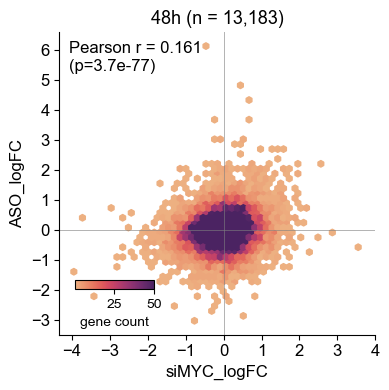

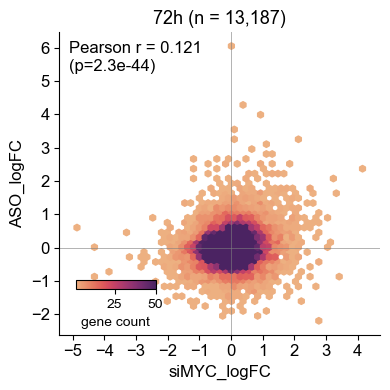

In [18]:
plot_correlation_hexbin(
    genes_deseq2,
    "siMYC_logFC",
    "ASO_logFC",
	"siMYC_logFC",
    "ASO_logFC"
)

/tmp/ipykernel_2040064/2549449317.py:148: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


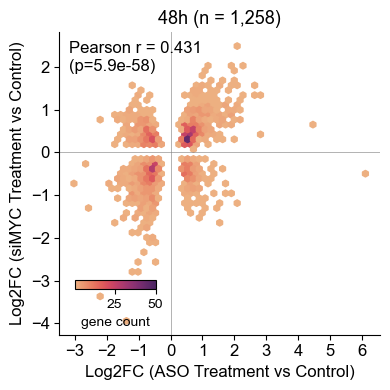

/tmp/ipykernel_2040064/2549449317.py:148: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


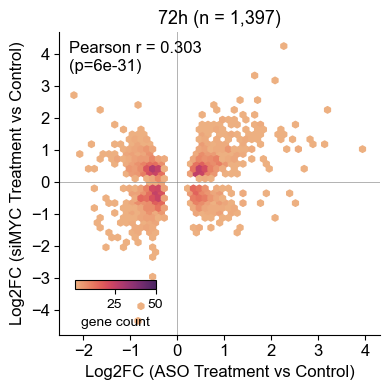

In [19]:
plot_correlation_hexbin(
    genes_deseq2_both_significant,
    "ASO_logFC",
	"siMYC_logFC",
	"Log2FC (ASO Treatment vs Control)",
    "Log2FC (siMYC Treatment vs Control)",
	save_path="/media/scratch/fy2306/projects/base_editing/plots/ASO/siMYC_corr.gene_both_significant"
)

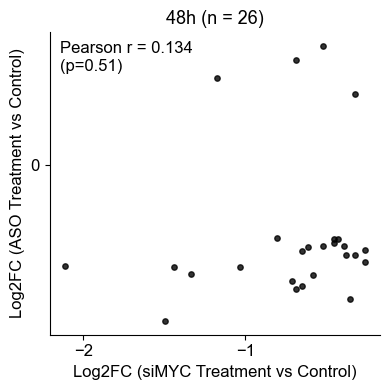

Quadrant counts for 48hh:
Q1 (siMYC > 0, ASO > 0): 0
Q2 (siMYC > 0, ASO < 0): 0
Q3 (siMYC < 0, ASO < 0): 22
Q4 (siMYC < 0, ASO > 0): 4


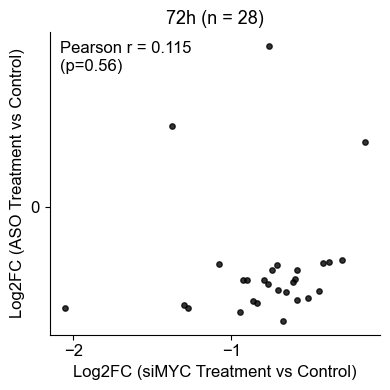

Quadrant counts for 72hh:
Q1 (siMYC > 0, ASO > 0): 0
Q2 (siMYC > 0, ASO < 0): 0
Q3 (siMYC < 0, ASO < 0): 25
Q4 (siMYC < 0, ASO > 0): 3


In [20]:
plot_correlation_scatter(
    genes_deseq2_myc_targets_v1,
    "siMYC_logFC",
    "ASO_logFC",
    "Log2FC (siMYC Treatment vs Control)",
    "Log2FC (ASO Treatment vs Control)",
	quadrant=True
)

#### Genes significant in both: siMYC and DESeq2 MYC-ASO

In [21]:
for timepoint, frame in genes_deseq2_both_significant.items():
    print(f"{timepoint}: {len(frame):,} genes significant in both")
    display(
        frame.assign(max_FDR=frame[["siMYC_FDR", "ASO_FDR"]].max(axis=1))
        .sort_values(["max_FDR", "gene_name"])
        [["EnsemblID", "gene_name", "siMYC_logFC", "ASO_logFC", "siMYC_FDR", "ASO_FDR", "same_direction"]]
    )

48h: 1,258 genes significant in both


,EnsemblID,gene_name,siMYC_logFC,ASO_logFC,siMYC_FDR,ASO_FDR,same_direction
103,ENSG00000115756,HPCAL1,-0.849921,-1.221099,6.446470e-14,9.355408e-12,True
304,ENSG00000110031,LPXN,-1.062180,-1.671634,2.291910e-11,2.774449e-11,True
376,ENSG00000112759,SLC29A1,-0.654382,-1.007676,6.041750e-11,1.525245e-11,True
385,ENSG00000184216,IRAK1,-0.698775,-1.240075,6.513410e-11,1.047815e-13,True
495,ENSG00000144354,CDCA7,-1.493670,-1.512108,2.936460e-10,7.583026e-12,True
...,...,...,...,...,...,...,...
3258,ENSG00000117335,CD46,-0.296718,0.435635,3.932810e-04,4.975034e-02,False
3896,ENSG00000256268,LINC02454,-1.397400,-1.406446,1.509840e-03,4.978190e-02,True
1965,ENSG00000099624,ATP5F1D,-0.342573,-0.500181,7.465820e-06,4.988531e-02,True
6528,ENSG00000100226,GTPBP1,-0.312521,0.503752,4.994850e-02,4.199908e-03,False


72h: 1,397 genes significant in both


,EnsemblID,gene_name,siMYC_logFC,ASO_logFC,siMYC_FDR,ASO_FDR,same_direction
148,ENSG00000117318,ID3,1.374780,2.495469,1.013640e-13,7.020616e-12,True
647,ENSG00000110031,LPXN,-1.136750,-1.160762,2.141620e-10,4.775082e-21,True
243,ENSG00000120254,MTHFD1L,-1.629470,-0.956078,8.487760e-13,4.757491e-10,True
675,ENSG00000144354,CDCA7,-1.342950,-0.922871,2.766120e-10,3.919299e-09,True
630,ENSG00000144136,SLC20A1,-0.585884,-0.735693,1.830040e-10,4.567146e-09,True
...,...,...,...,...,...,...,...
5324,ENSG00000130584,ZBTB46,1.366070,1.432602,3.426950e-03,4.977372e-02,True
7531,ENSG00000128185,DGCR6L,0.238716,-0.641651,4.979000e-02,3.569002e-02,False
7534,ENSG00000120509,PDZD11,0.143360,-0.395947,4.980730e-02,3.476351e-02,False
5275,ENSG00000183943,PRKX,-0.525529,-0.546539,3.186980e-03,4.988672e-02,True


### Hallmark gene-set NES correlations: siMYC versus DESeq2 MYC-ASO

In [22]:
hallmarks_deseq2 = {
    timepoint: load_shared_hallmarks_deseq2(files["siMYC_hallmarks"], files["ASO_hallmarks"])
    for timepoint, files in DESEQ2_INPUTS.items()
}
hallmarks_deseq2_both_significant = {
    tp: frame.loc[frame["both_significant"]].copy() for tp, frame in hallmarks_deseq2.items()
}

hallmark_deseq2_counts = pd.DataFrame({
    tp: {
        "all shared hallmark sets": len(frame),
        "significant in both": frame["both_significant"].sum(),
        "both significant, same direction": (frame["both_significant"] & frame["same_direction"]).sum(),
    }
    for tp, frame in hallmarks_deseq2.items()
}).T
hallmark_deseq2_counts

,all shared hallmark sets,significant in both,"both significant, same direction"
48h,50,10,7
72h,50,9,8


In [23]:
hallmark_deseq2_correlation_summary = pd.concat([
    correlation_summary(
        hallmarks_deseq2, "siMYC_NES", "ASO_NES", "all shared hallmark sets"
    ),
    correlation_summary(
        hallmarks_deseq2_both_significant, "siMYC_NES", "ASO_NES", "significant in both"
    ),
])
hallmark_deseq2_correlation_summary

,,n,pearson_r,pearson_p,spearman_rho,spearman_p
timepoint,subset,,,,,
48h,all shared hallmark sets,50,0.396322,0.004383,0.337911,0.016394
72h,all shared hallmark sets,50,0.330871,0.018927,0.358559,0.010561
48h,significant in both,10,0.547031,0.101741,0.539394,0.107593
72h,significant in both,9,0.839750,0.004620,0.866667,0.002495


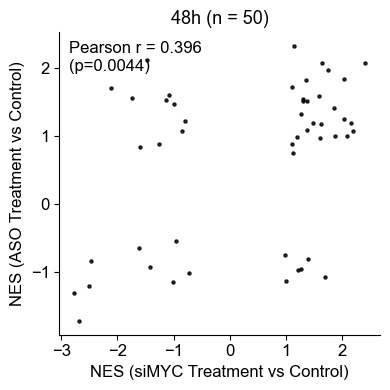

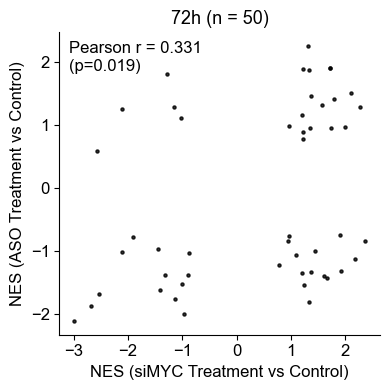

In [24]:
plot_correlation_scatter(
    hallmarks_deseq2,
    "siMYC_NES",
    "ASO_NES",
    "NES (siMYC Treatment vs Control)",
    "NES (ASO Treatment vs Control)",
    point_size=5,
)

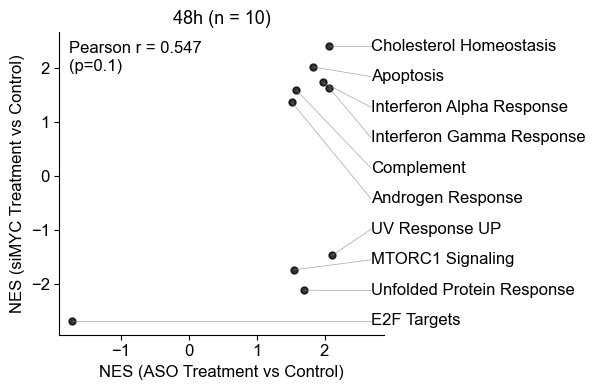

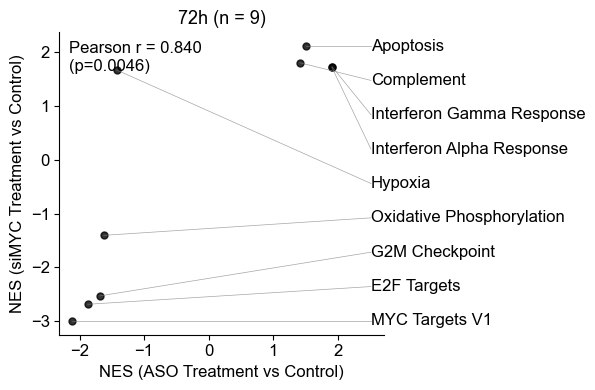

In [25]:
plot_correlation_scatter(
    hallmarks_deseq2_both_significant,
	"ASO_NES",
    "siMYC_NES",
    "NES (ASO Treatment vs Control)",
    "NES (siMYC Treatment vs Control)",
    point_size=25,
    annotate="TERM",
	save_path="/media/scratch/fy2306/projects/base_editing/plots/ASO/siMYC_corr.hallmark_both_significant"
)

#### Hallmark sets significant in both: siMYC and DESeq2 MYC-ASO

In [26]:
for timepoint, frame in hallmarks_deseq2_both_significant.items():
    print(f"{timepoint}: {len(frame):,} hallmark sets significant in both")
    display(
        frame.assign(
            max_adjusted_p=frame[["siMYC_FDR_Q_VAL", "ASO_FDR_Q_VAL"]].max(axis=1)
        )
        .sort_values(["max_adjusted_p", "TERM"])
        [["TERM", "hallmark_id", "siMYC_NES", "ASO_NES", "siMYC_FDR_Q_VAL", "ASO_FDR_Q_VAL", "same_direction"]]
    )

48h: 10 hallmark sets significant in both


,TERM,hallmark_id,siMYC_NES,ASO_NES,siMYC_FDR_Q_VAL,ASO_FDR_Q_VAL,same_direction
10,Apoptosis,HALLMARK_APOPTOSIS,2.021175,1.831600,0.001000,1.494430e-04,True
4,Cholesterol Homeostasis,HALLMARK_CHOLESTEROL_HOMEOSTASIS,2.408136,2.068582,0.001000,1.494430e-04,True
1,E2F Targets,HALLMARK_E2F_TARGETS,-2.683746,-1.714323,0.001000,2.259961e-04,True
7,Unfolded Protein Response,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,-2.116601,1.696587,0.001000,2.113226e-03,False
13,Interferon Alpha Response,HALLMARK_INTERFERON_ALPHA_RESPONSE,1.738119,1.971040,0.002963,1.494430e-04,True
14,MTORC1 Signaling,HALLMARK_MTORC1_SIGNALING,-1.736914,1.554440,0.001000,3.963484e-03,False
16,Interferon Gamma Response,HALLMARK_INTERFERON_GAMMA_RESPONSE,1.633316,2.070766,0.007274,3.938237e-07,True
21,Complement,HALLMARK_COMPLEMENT,1.591152,1.586496,0.007966,4.162854e-03,True
22,UV Response UP,HALLMARK_UV_RESPONSE_UP,-1.470953,2.110417,0.020366,5.195589e-07,False
27,Androgen Response,HALLMARK_ANDROGEN_RESPONSE,1.372385,1.516317,0.048490,2.944793e-02,True


72h: 9 hallmark sets significant in both


,TERM,hallmark_id,siMYC_NES,ASO_NES,siMYC_FDR_Q_VAL,ASO_FDR_Q_VAL,same_direction
1,E2F Targets,HALLMARK_E2F_TARGETS,-2.683275,-1.872878,0.001000,1.349448e-05,True
3,G2M Checkpoint,HALLMARK_G2M_CHECKPOINT,-2.527327,-1.683806,0.001000,2.905316e-04,True
0,MYC Targets V1,HALLMARK_MYC_TARGETS_V1,-2.992087,-2.111372,0.001000,4.049209e-08,True
16,Interferon Gamma Response,HALLMARK_INTERFERON_GAMMA_RESPONSE,1.728376,1.909585,0.002176,1.417568e-05,True
17,Interferon Alpha Response,HALLMARK_INTERFERON_ALPHA_RESPONSE,1.717901,1.906289,0.002374,2.775373e-04,True
7,Apoptosis,HALLMARK_APOPTOSIS,2.110788,1.502001,0.001000,2.012173e-02,True
18,Hypoxia,HALLMARK_HYPOXIA,1.665647,-1.422231,0.005440,2.632095e-02,False
14,Complement,HALLMARK_COMPLEMENT,1.800738,1.411641,0.001000,3.824968e-02,True
23,Oxidative Phosphorylation,HALLMARK_OXIDATIVE_PHOSPHORYLATION,-1.403727,-1.626878,0.042500,7.331831e-04,True
